In [137]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import math
from datetime import timedelta

import warnings
warnings.filterwarnings('ignore')

In [58]:
df = pd.read_csv('dataset_wellbore/merged_1000_eval_results_deepseek_v32.xlsx - results.csv')

In [52]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   conversation_id      1000 non-null   object        
 1   close_source         1000 non-null   object        
 2   conversation_type    1000 non-null   object        
 3   create_time          1000 non-null   object        
 4   close_time           1000 non-null   object        
 5   changeout_biztype    1000 non-null   object        
 6   current_biztype      1000 non-null   object        
 7   conversation_text    1000 non-null   object        
 8   request_json         1000 non-null   object        
 9   qc_detail            1000 non-null   object        
 10  detected_rule_codes  1000 non-null   object        
 11  tanggal_pengerjaan   656 non-null    datetime64[ns]
 12  nama_qc              1000 non-null   object        
 13  result_qc            1000 non-null

In [82]:
df_clean = (
    df.copy()
    .fillna('NA')
)

# cleaning column names
df_clean.columns = (
    df_clean
    .columns.str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# data type
df_clean['tanggal_pengerjaan'] = pd.to_datetime(df_clean['tanggal_pengerjaan'], errors='coerce')

# filling date NA
today = df_clean['tanggal_pengerjaan'].max()
df_clean['tanggal_pengerjaan'] = df_clean['tanggal_pengerjaan'].fillna(today)

# imputation
df_clean = df_clean.iloc[:, 11:32]

# categorical columns
cat_cols = [i for i in df_clean.columns if df_clean[i].dtype == 'object']

# lowering all the data
df_clean = df_clean.applymap(lambda x: x.lower() if isinstance(x, str) else x)
df_clean = df_clean.applymap(lambda x: x.replace(' ', '_') if isinstance(x, str) else x)

df_clean

,tanggal_pengerjaan,nama_qc,result_qc,result_qc_2,result_qc_3,result_qc_4,result_qc_5,result_qc_6,result_qc_7,code,...,code_3,code_4,code_5,code_6,code_7,description,description_2,description_3,description_4,description_5
0,2026-04-14,azer,correct,na,na,na,na,na,na,na,...,na,na,na,na,na,na,na,na,na,na
1,2026-04-14,azer,normal_conversation,na,na,na,na,na,na,na,...,na,na,na,na,na,na,na,na,na,na
2,2026-04-14,azer,correct,na,na,na,na,na,na,na,...,na,na,na,na,na,na,na,na,na,na
3,2026-04-14,azer,correct,na,na,na,na,na,na,na,...,na,na,na,na,na,na,na,na,na,na
4,2026-04-14,azer,correct,na,na,na,na,na,na,na,...,na,na,na,na,na,na,na,na,na,na
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2026-04-24,na,na,na,na,na,na,na,na,na,...,na,na,na,na,na,na,na,na,na,na
996,2026-04-24,na,na,na,na,na,na,na,na,na,...,na,na,na,na,na,na,na,na,na,na
997,2026-04-24,na,na,na,na,na,na,na,na,na,...,na,na,na,na,na,na,na,na,na,na
998,2026-04-24,na,na,na,na,na,na,na,na,na,...,na,na,na,na,na,na,na,na,na,na


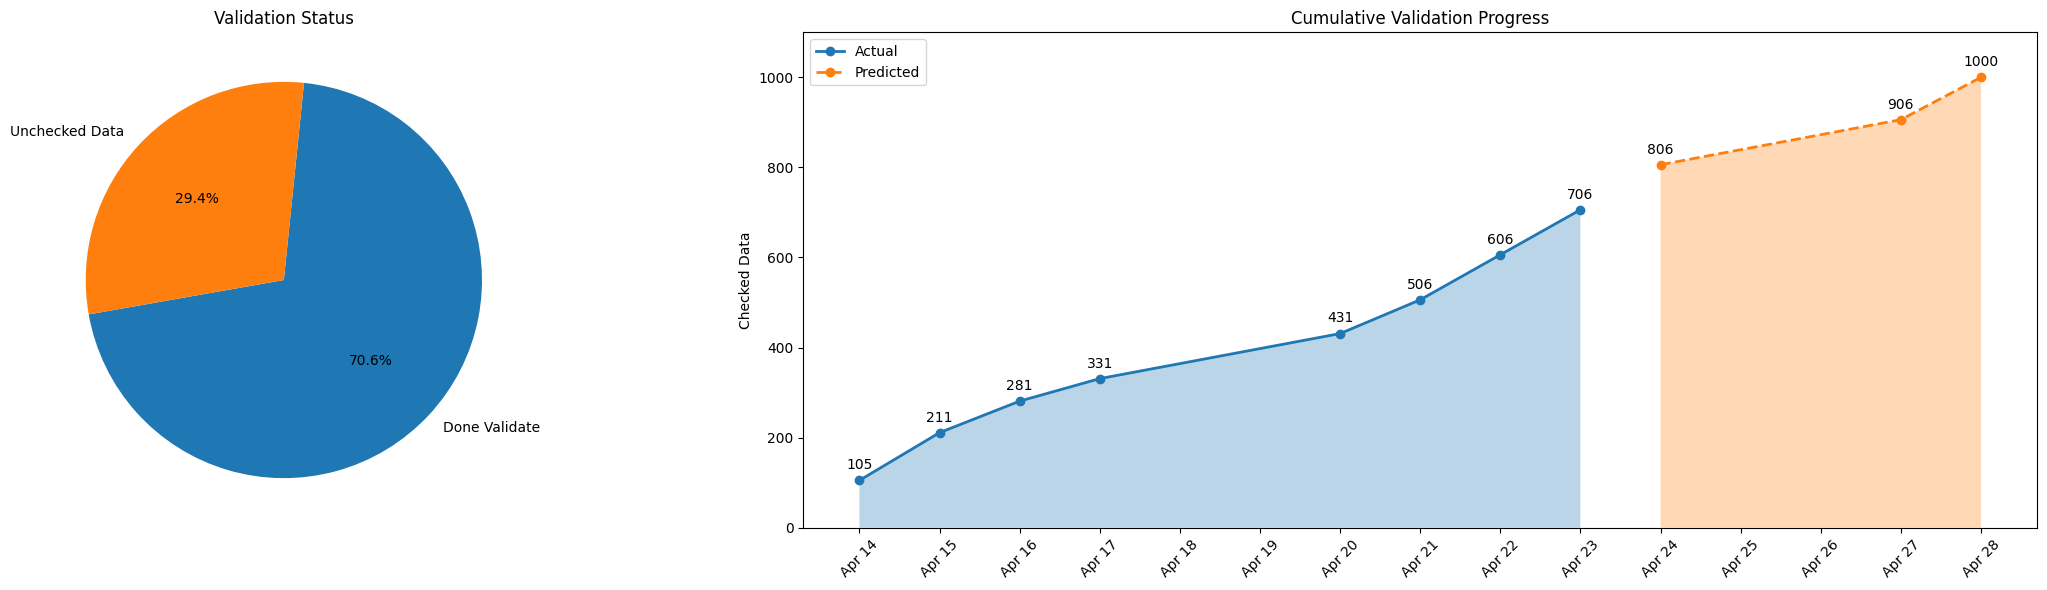

In [147]:
# imputation
today = df_clean['tanggal_pengerjaan'].max()
checked_data = df_clean[df_clean['tanggal_pengerjaan'] < today]
unchecked_data = df_clean[df_clean['tanggal_pengerjaan'] >= today]

# prediction setup
daily_capacity = 100
remaining_data = len(unchecked_data)
days_needed = math.ceil(remaining_data / daily_capacity)
estimated_finish = today + timedelta(days=days_needed)

# actual progress
daily_progress = checked_data.groupby('tanggal_pengerjaan').size().cumsum()

# predicted cumulative progress (weekday only)
pred_dates = pd.bdate_range(
    start=daily_progress.index[-1] + timedelta(days=1),
    periods=days_needed
)

last_value = daily_progress.iloc[-1]
pred_values = []

for i in range(1, days_needed + 1):
    next_value = min(last_value + i * daily_capacity, len(df_clean))
    pred_values.append(next_value)

estimated_finish = pred_dates[-1]

# visualization
fig, axes = plt.subplots(1, 2, figsize=(24, 6))

# pie chart
labels = ['Done Validate', 'Unchecked Data']
sizes = [len(checked_data), len(unchecked_data)]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=190)
axes[0].set_title('Validation Status')

# actual line
axes[1].plot(
    daily_progress.index,
    daily_progress.values,
    marker='o',
    linewidth=2,
    label='Actual'
)

axes[1].fill_between(
    daily_progress.index,
    daily_progress.values,
    alpha=0.3
)

# predicted line
axes[1].plot(
    pred_dates,
    pred_values,
    marker='o',
    linestyle='--',
    linewidth=2,
    label='Predicted'
)

axes[1].fill_between(
    pred_dates,
    pred_values,
    alpha=0.3
)

# labels actual
for x, y in zip(daily_progress.index, daily_progress.values):
    axes[1].annotate(
        f'{y}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center'
    )

# labels predicted
for x, y in zip(pred_dates, pred_values):
    axes[1].annotate(
        f'{y}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center'
    )

# formatting
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=1))
axes[1].tick_params(axis='x', rotation=45)

axes[1].set_title('Cumulative Validation Progress')
axes[1].set_ylabel('Checked Data')
axes[1].set_ylim(0, 1100)
axes[1].legend()

plt.tight_layout()
plt.show()